GRADIENT DESCENT

In [ ]:
# error = actual value - predicted value 
#Gradient Descent reduces error by adjusting the weights little by little.
#After each prediction, it checks the error and updates the weights in the direction that reduces the error.
#This process repeats until the model reaches very low error.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
# let create data 
data =pd.DataFrame({'week':[1,2,3,4,5,6,7,8,9,10],'car_sold':[5,9,4,15,7,20,11,25,18,30]})
print(data)

   week  advertisement  price_drop  car_sold
0     1              2           0         5
1     2              1           1         7
2     3              3           0         9
3     4              5           1        15
4     5              4           1        14


In [40]:
mean_x=np.mean(data['week'])
mean_y=np.mean(data['car_sold'])
print('mean of x',mean_x)
print('mean of y',mean_y)

mean of x 5.5
mean of y 14.4


In [41]:
x=data['week']
y=data['car_sold']
summation=0
for i,j in zip(x,y):
  x_divation=mean_x-i
  y_divation=mean_y-j
  mul_x_y=x_divation*y_divation
  summation=mul_x_y+summation
print(summation)
summation1=0
for k in x:
  x_divite=(mean_x-k)**2
  summation1=x_divite+summation1
print(summation1)
print(summation)  
#m= Σ(x - x̄)²(y - ȳ)²/Σ(x - x̄)²
m=summation/summation1
print(f'm-slop:{m}')
# to find c value ȳ=𝑚x̄+𝑐
#ȳ=y_mean,x̄=x_mean
c=mean_y-(m*3)
print(c)
#y=0.6x+2.2
#now we want to apply all the x value to find the predicted value y
value=[]
for x in data['week']:
  pred_y=(m*x)+c
  value.append(round(float(pred_y),1))
print(value)

197.0
82.5
197.0
m-slop:2.3878787878787877
7.236363636363637
[9.6, 12.0, 14.4, 16.8, 19.2, 21.6, 24.0, 26.3, 28.7, 31.1]


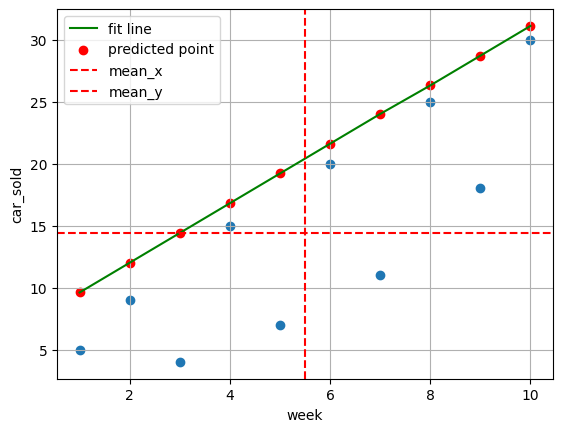

In [42]:
# now we get the preducted value 
plt.scatter(data['week'],data['car_sold'])
plt.xlabel('week')
plt.ylabel('car_sold')
plt.plot(data['week'],value,color='green',label='fit line')
plt.scatter(data['week'],value,color='red',marker='o',label='predicted point')
plt.axvline(x=mean_x,color='red',linestyle='--',label='mean_x')
plt.axhline(y=mean_y,color='red',linestyle='--',label='mean_y')
plt.legend()
plt.grid()
plt.show()

In [43]:
actual_value=[]
predicted_Value=[]
for a,p in zip(data['car_sold'],value):
  actual_value.append(a)
  predicted_Value.append(p)
print(f'actual value:{actual_value}')
print(f' predicted value:{predicted_Value}')


actual value:[5, 9, 4, 15, 7, 20, 11, 25, 18, 30]
 predicted value:[9.6, 12.0, 14.4, 16.8, 19.2, 21.6, 24.0, 26.3, 28.7, 31.1]


In [44]:
# residual error
error = []
for r2 in range(len(data['car_sold'])):
    residual = actual_value[r2] - predicted_Value[r2]
    error.append(round(residual, 1))
print("Residual Error:", error)
# squared error
square_error = []
for e2 in range(len(error)):
    square_error.append(error[e2] * error[e2])
print("Squared Error:", square_error)
# sum of squared error
sum_of_error = sum(square_error)
# Mean Squared Error
mse = sum_of_error / len(square_error)
print("Mean Squared Error:", round(mse, 2))

Residual Error: [-4.6, -3.0, -10.4, -1.8, -12.2, -1.6, -13.0, -1.3, -10.7, -1.1]
Squared Error: [21.159999999999997, 9.0, 108.16000000000001, 3.24, 148.83999999999997, 2.5600000000000005, 169.0, 1.6900000000000002, 114.48999999999998, 1.2100000000000002]
Mean Squared Error: 57.93


In [45]:
# We apply GRADIENT DESCENT to reduce the error.
# Gradient Descent works like this:
# 1. Initially, the m (slope) and c (intercept) values are calculated or initialized.
#    Here we got:
#    m = 0.8
#    c = 3.5
# 2. In Machine Learning, m becomes the weight and c becomes the bias/intercept.
# 3. The model updates the weight and bias step by step using the learning rate. (Learning rate means how big or small the learning step should be.)
# 4. After updating the values, the model predicts again and compares the prediction with the actual values
# 5. If the error decreases, the model continues updating the weights and bias again and again.
# 6. This process repeats until the error becomes very small.
#    This is how Gradient Descent works.

Epoch: 0
m: 1.78
c: 3.63
MSE: 85.25
----------------
Epoch: 200
m: 2.24
c: 2.3
MSE: 22.43
----------------
Epoch: 400
m: 2.32
c: 1.71
MSE: 22.24
----------------
Epoch: 600
m: 2.36
c: 1.46
MSE: 22.21
----------------
Epoch: 800
m: 2.38
c: 1.35
MSE: 22.2
----------------
Final Weight (m): 2.38
Final Bias (c): 1.3
MSE: 22.2


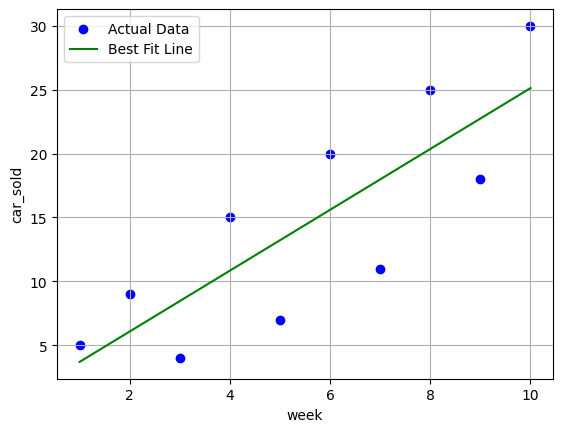

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# dataset
data = pd.DataFrame({
    'week': [1,2,3,4,5,6,7,8,9,10],
    'car_sold': [5,9,4,15,7,20,11,25,18,30]
})

# x and y values
x = data['week']
y = data['car_sold']

# initial weight and bias
m = 0.8
c =3.5

# learning rate
lr = 0.01

# epochs = how many times model learns
epochs = 1000

n = len(x)

# Gradient Descent
for i in range(epochs):
    

    predicted_y = (m * x) + c

    # error
    error = y - predicted_y

    # gradients
    dm = (-2/n) * sum(x * error)
    dc = (-2/n) * sum(error)

    # update weight and bias
    m = m - (lr * dm)
    c = c - (lr * dc)
    if i % 200 == 0:
        mse = sum((y - predicted_y)**2) / n
        print("Epoch:", i)
        print("m:", round(m,2))
        print("c:", round(c,2))
        print("MSE:", round(mse,2))
        print("----------------")

# final prediction
final_prediction = (m * x) + c

print("Final Weight (m):", round(m,2))
print("Final Bias (c):", round(c,2))
# Mean Squared Error
mse = sum((y - final_prediction)**2) / n
print("MSE:", round(mse,2))

# graph
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x, final_prediction, color='green', label='Best Fit Line')

plt.xlabel('week')
plt.ylabel('car_sold')

plt.legend()
plt.grid()

plt.show()

Final Weight: 1.3463738857727623e-08


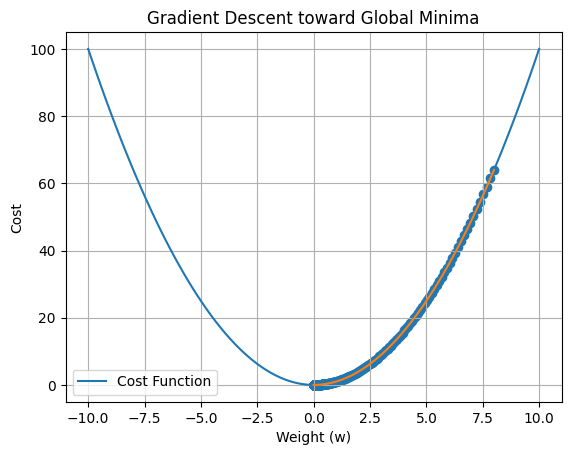

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# weight values
w = np.linspace(-10, 10, 100)

# cost function (U-shape)
cost = w**2

# starting point
current_w = 8

# learning rate
lr = 0.01

# store points
w_history = [current_w]
cost_history = [current_w**2]

# Gradient Descent
for i in range(1000):

    # derivative of w² = 2w
    gradient = 2 * current_w

    # update weight
    current_w = current_w - (lr * gradient)

    # store updated values
    w_history.append(current_w)
    cost_history.append(current_w**2)


print("Final Weight:", current_w)

# plot cost function
plt.plot(w, cost, label='Cost Function')

# plot Gradient Descent steps
plt.scatter(w_history, cost_history)

# connect points
plt.plot(w_history, cost_history)

plt.xlabel('Weight (w)')
plt.ylabel('Cost')
plt.title('Gradient Descent toward Global Minima')

plt.grid()
plt.legend()

plt.show()

In [ ]:
# now m-slop:2.38 c-7.23 the Mean Squared Error: 57.93 is reduce to Final Weight (m): 2.38 Final Bias (c): 1.3 MSE: 22.2 by using GRADIENT DESCENT